# Understanding Chess Structures Using Unsupervised Learning
**Student:** Artem Okhten  
**Course:** MTH 4224 – Intro to Machine Learning  
**Term:** Spring 2026

## Abstract

In this project I use unsupervised learning to study structure in chess games. Instead of predicting winner of game, I extract features from first 20 full moves and cluster games based on tactical activity, pawn structure, castling behavior, center control, material volatility, opening family, and Stockfish evaluation volatility.

The main question is whether chess games naturally separate into groups like tactical, positional, or balanced. I parsed 10,000 games from Lichess and, after preprocessing and outlier filtering, used 8,621 games with 43 numerical features for clustering. PCA showed that the first two principal components explain only about 13.92% of total variance, and the 2D projection looked like one broad cloud rather than separated islands.

The main clustering models showed weak separation when all features were used together. K-Means, Gaussian Mixture, Agglomerative Clustering, and DBSCAN all produced low silhouette scores in full feature space. However, feature group comparison gave a more useful result. Dynamic features produced much stronger clustering signal than the full feature set, and ECO/opening features also created clear structure that should be interpreted as opening-family structure, not pure playing style.

The main finding is that chess games do not form clean style categories in the full engineered feature space. Instead, they behave more like continuous spectrum. Some structure exists, but it depends strongly on which type of information is used: dynamic activity, opening family, or positional structure.

## Research Questions

This project focuses on three questions:

1. Do chess games form natural clusters when described by engineered early-game features?
2. Are clusters more influenced by dynamic features, like captures and volatility, or structural features, like pawn structure and center control?
3. Can DBSCAN identify sparse or unusual regions of the feature space better than general clustering methods?

These questions are important because unsupervised learning does not have true labels. There is no official label saying that one game is tactical and another is positional. The goal is not to prove exact chess styles, but to test whether feature space has interpretable structure.

## 1. Introduction

In this project we try to see if it is possible to find structure in chess games using unsupervised learning. Instead of predicting result of game, we group games based on how they are played during the first 20 full moves.

This problem is more difficult than a normal classification problem because there are no true labels for style. In supervised learning, model can be checked directly using accuracy or another metric. Here, the goal is different. We are not trying to prove that every game belongs to one exact category. Instead, we want to test whether feature space itself has any natural structure.

One important question in this project is whether chess games really separate into clear groups such as tactical, positional, or balanced games. My initial expectation was that some of these groups would appear, but I also expected that separation may not be very clean because chess games usually exist on a spectrum.

To represent games, we extract different types of features. Some of them are structural, like pawn structure, center control, castling timing, and king danger. Others are dynamic, like material changes, checks, captures, and evaluation volatility. Stockfish is used not to decide final winner of game, but to measure how unstable position is during first 20 full moves.

After that we apply several clustering methods and compare their results. The goal is not only to find clusters, but also to understand what kind of information creates the strongest separation: dynamic activity, opening family, or positional structure.

## 2. Data Parsing & Engine Integration

The dataset used in this project comes from the Lichess database. Games are stored in PGN format, and each game contains move sequence and basic metadata such as opening code.

We limit the analysis to the first part of the game, strictly the first 20 full moves. This is where many early structural and strategic differences already appear. Later stages are more chaotic and harder to compare objectively, because games can enter very different tactical or endgame situations.

In the original proposal, we planned to use the first 15 moves of each game. During implementation, we extended this to the first 20 full moves. We made this change because 15 moves sometimes did not give enough information about castling, pawn structure changes, and early middlegame tension. Using 20 moves still keeps analysis focused on early game, but it gives more complete features for clustering.

Stockfish is used only for evaluation-based features such as evaluation volatility and mean absolute evaluation. We do not use final game result as target label, because this is unsupervised project. The engine is included to measure how unstable or imbalanced a position becomes during the first 20 moves.

Below is the pipeline we used to parse these games, integrate Stockfish for evaluation metrics, and convert raw PGN moves into numerical feature set.

In [1]:
import os
import sys
import time
import asyncio
import chess
import chess.pgn
import chess.engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from IPython.display import display

# Fix for asyncio subprocesses on Windows
if sys.platform == 'win32':
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

# Visualization settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
def get_pawn_structures(board, color):
    """Calculates doubled, isolated, passed pawns, and pawn islands strictly using chess rules."""
    pawns = board.pieces(chess.PAWN, color)
    enemy_pawns = board.pieces(chess.PAWN, not color)
    
    files_with_pawns = [chess.square_file(sq) for sq in pawns]
    unique_files = sorted(list(set(files_with_pawns)))
    
    # Doubled pawns: total pawns minus unique files occupied by pawns
    doubled = len(files_with_pawns) - len(unique_files)
    
    # Pawn Islands
    islands = 0
    if unique_files:
        islands = 1
        for i in range(1, len(unique_files)):
            if unique_files[i] - unique_files[i-1] > 1:
                islands += 1
    
    isolated = 0
    passed = 0
    
    for sq in pawns:
        f = chess.square_file(sq)
        r = chess.square_rank(sq)
        
        # Isolated check: no friendly pawns on adjacent files
        if (f - 1) not in unique_files and (f + 1) not in unique_files:
            isolated += 1
            
        # Passed check: no enemy pawns in front on the same or adjacent files
        is_passed = True
        for ep_sq in enemy_pawns:
            ep_f = chess.square_file(ep_sq)
            ep_r = chess.square_rank(ep_sq)
            if abs(ep_f - f) <= 1:  # Same or adjacent file
                if (color == chess.WHITE and ep_r > r) or (color == chess.BLACK and ep_r < r):
                    is_passed = False
                    break
                    
        if is_passed:
            passed += 1
            
    return doubled, isolated, passed, islands

def evaluate_king_safety(board, color):
    """Measures King Danger by counting enemy attacks on the 8 squares immediately surrounding the King."""
    king_sq = board.king(color)
    if king_sq is None: return 0
    enemy = not color
    
    king_zone = [sq for sq in chess.SQUARES if king_sq is not None and chess.square_distance(king_sq, sq) <= 1]
    danger = sum(1 for sq in king_zone if board.is_attacked_by(enemy, sq))
    return danger

def calculate_center_control(board, color):
    """Measures weighted attacks on both core and extended central squares."""
    core = [chess.D4, chess.E4, chess.D5, chess.E5]
    extended = [chess.C3, chess.D3, chess.E3, chess.F3,
                chess.C4, chess.F4, chess.C5, chess.F5,
                chess.C6, chess.D6, chess.E6, chess.F6]
    
    ctrl = sum(2 for sq in core if board.is_attacked_by(color, sq))
    ctrl += sum(1 for sq in extended if board.is_attacked_by(color, sq))
    return ctrl

def extract_features(game, engine=None, max_plies=40):
    """Parses a PGN object and extracts comprehensive metrics."""
    board = game.board()
    features = {
        'w_capture_val': 0, 'b_capture_val': 0,  # Weighted by piece value
        'w_checks': 0, 'b_checks': 0,
        'w_castle_ply': max_plies, 'b_castle_ply': max_plies,
        'w_minor_moves': 0, 'b_minor_moves': 0,  # Tempo/Development measurement
        'eco_prefix': game.headers.get("ECO", "A00")[:3]
    }
    
    EVAL_PLIES = {8, 16, 24, 32, 40}  # Evaluate every 4 full moves to save compute time
    evaluations = []
    material_imbalances = []
    piece_values = {chess.PAWN: 1, chess.KNIGHT: 3, chess.BISHOP: 3, chess.ROOK: 5, chess.QUEEN: 9, chess.KING: 0}

    ply = 0
    for move in game.mainline_moves():
        if ply >= max_plies: break
            
        is_white = board.turn == chess.WHITE
        
        # Weighted Captures
        if board.is_capture(move):
            if board.is_en_passant(move):
                cap_val = 1
            else:
                captured_piece = board.piece_at(move.to_square)
                cap_val = piece_values.get(captured_piece.piece_type, 1) if captured_piece else 1
                
            if is_white: features['w_capture_val'] += cap_val
            else: features['b_capture_val'] += cap_val
            
        # Tempo tracking: Count minor piece movements to gauge development speed
        moving_piece = board.piece_at(move.from_square)
        if moving_piece and moving_piece.piece_type in [chess.KNIGHT, chess.BISHOP]:
            if is_white: features['w_minor_moves'] += 1
            else: features['b_minor_moves'] += 1
            
        # Castling Tracking
        if board.is_castling(move):
            if is_white and features['w_castle_ply'] == max_plies: features['w_castle_ply'] = ply
            if not is_white and features['b_castle_ply'] == max_plies: features['b_castle_ply'] = ply
            
        board.push(move)
        
        if board.is_check():
            if is_white: features['w_checks'] += 1
            else: features['b_checks'] += 1
            
        # Material Dynamics (Computed every ply for accurate variance)
        w_mat = sum(piece_values[p.piece_type] for p in board.piece_map().values() if p.color == chess.WHITE)
        b_mat = sum(piece_values[p.piece_type] for p in board.piece_map().values() if p.color == chess.BLACK)
        material_imbalances.append(w_mat - b_mat)
        
        # Engine Evaluation with safe exception handling & mate capping (±15 pawns max)
        if engine and (ply + 1) in EVAL_PLIES:
            try:
                info = engine.analyse(board, chess.engine.Limit(time=0.1))
                pov_score = info['score'].pov(chess.WHITE)
                if pov_score.is_mate():
                    sf_eval = 15.0 if pov_score.mate() > 0 else -15.0
                else:
                    cp_score = pov_score.score(mate_score=1500)
                    sf_eval = max(-15.0, min(15.0, cp_score / 100.0))
                evaluations.append(sf_eval)
            except Exception as e:
                evaluations.append(0.0)
                
        ply += 1

    # Post-opening board geometry and structural features
    features['w_dbl_p'], features['w_iso_p'], features['w_pass_p'], features['w_islands'] = get_pawn_structures(board, chess.WHITE)
    features['b_dbl_p'], features['b_iso_p'], features['b_pass_p'], features['b_islands'] = get_pawn_structures(board, chess.BLACK)
    
    features['w_center_ctrl'] = calculate_center_control(board, chess.WHITE)
    features['b_center_ctrl'] = calculate_center_control(board, chess.BLACK)
    
    features['w_king_danger'] = evaluate_king_safety(board, chess.WHITE)
    features['b_king_danger'] = evaluate_king_safety(board, chess.BLACK)
    
    # Dynamic & Engine statistics
    features['material_volatility'] = np.var(material_imbalances) if len(material_imbalances) > 1 else 0
    features['eval_volatility'] = np.var(evaluations) if len(evaluations) > 1 else 0
    features['mean_abs_eval'] = np.mean([abs(e) for e in evaluations]) if evaluations else 0

    return features

def get_or_parse_dataset(pgn_path, csv_path, max_games=10000, engine_path=None):
    """
    Loads parsed data from CSV if available, otherwise parses the PGN and saves to CSV.
    """
    if os.path.exists(csv_path):
        print(f"Loading previously parsed dataset from '{csv_path}'")
        return pd.read_csv(csv_path)
        
    if not os.path.exists(pgn_path):
        raise FileNotFoundError(f"Dataset file {pgn_path} not found.")
        
    engine = None
    if engine_path:
        print(f"Attempting to start Stockfish at path {engine_path}")
        engine = chess.engine.SimpleEngine.popen_uci(engine_path)
        print('Stockfish engine initialized successfully.')

    print(f'Parsing up to {max_games} games from {pgn_path}')
    start_time = time.time()
    data = []
    games_processed = 0

    with open(pgn_path, encoding="utf-8", errors="ignore") as pgn:
        while games_processed < max_games:
            game = chess.pgn.read_game(pgn)
            if game is None: break
            
            # make sure game has at least 20 full moves = 40 plies
            moves = list(game.mainline_moves())
            if len(moves) < 40:
                continue 
                
            data.append(extract_features(game, engine=engine, max_plies=40))
            games_processed += 1
            
            if games_processed % 500 == 0:
                print(f'Processed {games_processed}/{max_games} games... ({(time.time() - start_time):.2f}s)')
            
    if engine: engine.quit()
        
    df = pd.DataFrame(data)
    df.to_csv(csv_path, index=False)
    print(f'Finished extracting {df.shape[0]} games. Saved to {csv_path}')
    return df

In [3]:
config = {
    'pgn_path': 'lichess_data.pgn',
    'csv_path': 'chess_dataset_parsed_20moves_v2.csv',
    'engine_path': r"C:\Users\darha\Documents\MTH 4224\project2\stockfish\stockfish.exe",
    'max_games': 10000
}

# Load dataset (will parse and create CSV on first run, load CSV instantly on subsequent runs)
df = get_or_parse_dataset(config['pgn_path'], config['csv_path'], config['max_games'], config['engine_path'])

# Advanced ECO Handling: Keep top 20 opening families, group the rest
if not df.empty and 'eco_prefix' in df.columns:
    top_ecos = df['eco_prefix'].value_counts().nlargest(20).index
    df['eco_group'] = df['eco_prefix'].where(df['eco_prefix'].isin(top_ecos), 'Other')
    df = pd.get_dummies(df, columns=['eco_group'], drop_first=True)
    df.drop(columns=['eco_prefix'], inplace=True)

df.head()

Attempting to start Stockfish at path C:\Users\darha\Documents\MTH 4224\project2\stockfish\stockfish.exe
Stockfish engine initialized successfully.
Parsing up to 10000 games from lichess_data.pgn
Processed 500/10000 games... (258.09s)
Processed 1000/10000 games... (516.00s)
Processed 1500/10000 games... (773.84s)
Processed 2000/10000 games... (1031.35s)
Processed 2500/10000 games... (1289.63s)
Processed 3000/10000 games... (1547.76s)
Processed 3500/10000 games... (1805.48s)
Processed 4000/10000 games... (2063.70s)
Processed 4500/10000 games... (2321.50s)
Processed 5000/10000 games... (2579.24s)
Processed 5500/10000 games... (2839.76s)
Processed 6000/10000 games... (3102.29s)
Processed 6500/10000 games... (3366.01s)
Processed 7000/10000 games... (3629.20s)
Processed 7500/10000 games... (3892.94s)
Processed 8000/10000 games... (4156.51s)
Processed 8500/10000 games... (4420.80s)
Processed 9000/10000 games... (4683.19s)
Processed 9500/10000 games... (4942.14s)
Processed 10000/10000 games..

,w_capture_val,b_capture_val,w_checks,b_checks,w_castle_ply,b_castle_ply,w_minor_moves,b_minor_moves,w_dbl_p,w_iso_p,...,eco_group_C00,eco_group_C02,eco_group_C20,eco_group_C23,eco_group_C40,eco_group_C41,eco_group_C50,eco_group_D00,eco_group_D02,eco_group_Other
0,14,14,2,1,40,40,4,6,0,1,...,False,False,False,False,False,False,False,False,False,True
1,19,20,0,2,20,23,8,8,0,0,...,False,False,True,False,False,False,False,False,False,False
2,28,26,1,0,18,40,6,5,0,0,...,False,False,False,False,False,False,False,False,False,False
3,9,12,0,0,10,29,7,8,1,1,...,False,False,False,False,False,True,False,False,False,False
4,13,11,0,0,10,13,8,9,0,1,...,False,False,False,False,False,False,False,False,False,True


## 3. Dataset Description & Feature Engineering

**Dataset Summary:**

| Metric | Count / Details |
| :--- | :--- |
| **Total games parsed** | 10,000 games were parsed, and after outlier filtering 8,621 games remained for clustering. |
| **Minimum Game Length** | 20 full moves |
| **Learning Type** | Unsupervised learning, no outcome labels used |

Main part of project is feature extraction. Raw chess games cannot be used directly, so I convert them into numerical features. To satisfy the project requirement of using at least 20 features, this pipeline avoids final game outcome labels and instead transforms the board state and game dynamics from the first 20 moves into numerical vectors.

Using `python-chess` and the Stockfish engine, I engineered 24 primary chess features. After one-hot encoding the top ECO opening groups, the final clustering matrix contained 43 numerical features. This means the project satisfies the dimensionality requirement, but still keeps feature space manageable for local computation.

| # | Feature Name | Description | Type |
| :--- | :--- | :--- | :--- |
| **1** | `eval_volatility` | Variance of Stockfish evaluations during selected early-game plies | Continuous |
| **2** | `mean_abs_eval` | Average absolute Stockfish evaluation, measuring overall imbalance | Continuous |
| **3** | `material_volatility` | Variance of material point difference during the first 20 moves | Continuous |
| **4** | `w_capture_val` | Weighted value of pieces captured by White | Continuous |
| **5** | `b_capture_val` | Weighted value of pieces captured by Black | Continuous |
| **6** | `w_checks` | Number of checks delivered by White | Discrete |
| **7** | `b_checks` | Number of checks delivered by Black | Discrete |
| **8** | `w_minor_moves` | Development activity: moves by White knights and bishops | Discrete |
| **9** | `b_minor_moves` | Development activity: moves by Black knights and bishops | Discrete |
| **10** | `w_castle_ply` | Half-move when White castled, or 40 if not castled | Discrete |
| **11** | `b_castle_ply` | Half-move when Black castled, or 40 if not castled | Discrete |
| **12** | `w_dbl_p` | Count of doubled pawns in White's structure | Discrete |
| **13** | `b_dbl_p` | Count of doubled pawns in Black's structure | Discrete |
| **14** | `w_iso_p` | Count of isolated pawns in White's structure | Discrete |
| **15** | `b_iso_p` | Count of isolated pawns in Black's structure | Discrete |
| **16** | `w_pass_p` | Count of passed pawns for White | Discrete |
| **17** | `b_pass_p` | Count of passed pawns for Black | Discrete |
| **18** | `w_islands` | Number of pawn islands for White | Discrete |
| **19** | `b_islands` | Number of pawn islands for Black | Discrete |
| **20** | `w_center_ctrl` | White's weighted control of core and extended center squares | Discrete |
| **21** | `b_center_ctrl` | Black's weighted control of core and extended center squares | Discrete |
| **22** | `w_king_danger` | Enemy attacks near White king | Discrete |
| **23** | `b_king_danger` | Enemy attacks near Black king | Discrete |
| **24** | `eco_group` | ECO opening group, later converted into one-hot columns | Categorical |

These features are not perfect descriptions of chess style, but they give a reasonable numerical summary of each game. Capture values, checks, material volatility, and evaluation volatility describe dynamic or tactical activity. Pawn islands, isolated pawns, center control, king danger, and castling timing describe more structural or positional parts of the game.

I included both dynamic and structural features because I wanted clustering algorithm to have more than one way to separate games. Later in the project, I also compare feature groups directly to see whether dynamic features, structural features, or ECO opening information create stronger clustering signal.

The ECO opening code was included because different openings can lead to different structures. However, I do not treat ECO as the same thing as playing style. ECO is opening-family information, so if it separates games well, that means opening choice creates structure in the data, not necessarily that the model found pure tactical or positional style labels.

## 4. Data Preprocessing

After extracting features, data needs to be cleaned and prepared before clustering. This step is important because most clustering methods use distances, and distance calculations can be strongly affected by scale, skewness, and extreme values.

First, missing values are removed. Boolean ECO dummy columns are converted to integers so that all variables can be used in numerical clustering models. Then I remove extreme rows using 1st and 99th percentile bounds on continuous features. This reduces the effect of rare games with extremely high volatility, capture values, or evaluation swings.

Some features have highly skewed distribution, so I apply `log1p` transformation only to skewed non-negative features. In my final run, this was applied to White checks, Black checks, Black passed pawns, material volatility, and evaluation volatility. I did not apply the same transformation to every feature, because some discrete structural features are already small counts and do not need it.

Finally, all numerical features are standardized with `StandardScaler`. This is necessary because K-Means, PCA, DBSCAN, and Agglomerative Clustering are all sensitive to scale. Without scaling, features with larger numerical ranges would dominate distance calculations and could make clusters reflect measurement scale more than chess structure.

In [4]:
df.dropna(inplace=True)

# Convert boolean columns to integers
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

temp_features = df.select_dtypes(include=[np.number]).columns
continuous_cols = [col for col in temp_features if df[col].nunique() > 5]

# 1. Extreme Percentile Filtering (1% - 99%)
before = df.shape[0]
lower_bound = df[continuous_cols].quantile(0.01)
upper_bound = df[continuous_cols].quantile(0.99)
df = df[~((df[continuous_cols] < lower_bound) | (df[continuous_cols] > upper_bound)).any(axis=1)]
after = df.shape[0]
print(f"Removed {before - after} rows as extreme outliers ({(before-after)/before:.2%})")

# 2. Verified Log Transformation for skewed features
skewed_features_logged = []
for col in continuous_cols:
    # Explicit check for skewness before transforming
    if col in df.columns and abs(df[col].skew()) > 1.5:
        if df[col].min() >= 0:  # log1p requires non-negative values
            df[col] = np.log1p(df[col])
            skewed_features_logged.append(col)

print(f"Applied log1p transform to dynamically detected skewed features: {skewed_features_logged}")

# 3. Standardization
all_features = df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[all_features])
df_scaled = pd.DataFrame(X_scaled, columns=all_features, index=df.index)
print(f"Data shape after preprocessing: {df.shape}")
print(f"\nTotal strategic features utilized for clustering: {len(all_features)}")

Removed 1379 rows as extreme outliers (13.79%)
Applied log1p transform to dynamically detected skewed features: ['w_checks', 'b_checks', 'b_pass_p', 'material_volatility', 'eval_volatility']
Data shape after preprocessing: (8621, 43)

Total strategic features utilized for clustering: 43


### Outlier Removal and Scaling

The outlier removal step removed 1,379 games, which is about 13.79% of the original parsed dataset. This is not a small amount, so I treated it carefully. The reason I removed these games is that clustering methods are very sensitive to extreme values. A few games with very high capture values or very high evaluation volatility can dominate distance calculations and make clusters depend mostly on rare games.

After preprocessing, the final dataset contained 8,621 games and 43 numerical features. This is still large enough for unsupervised learning and also satisfies the project requirement of using at least 20 features.

At the same time, this filtering is also a limitation. Some of the removed games may represent real tactical or unusual chess games. Therefore, the final clustering results should be understood as describing the main body of typical games, not every possible chess game.

## 5. Exploratory Analysis

Before applying clustering models, I first look at basic properties of the data. This step helps explain why the later clustering scores are not very high.

From the feature distributions, some variables have long tails, especially capture values, checks, material volatility, and evaluation volatility. This means that most games are relatively normal, but some games are much more tactical or unstable during the first 20 full moves.

Some features are also related to each other. For example, high capture values often appear together with higher volatility, because active tactical games usually change material balance and engine evaluation more quickly.

This already suggests that clustering may be influenced more by dynamic features than by static structural features. It also suggests why the full feature space may be difficult to cluster cleanly: different types of chess information are mixed together in the same numerical representation.

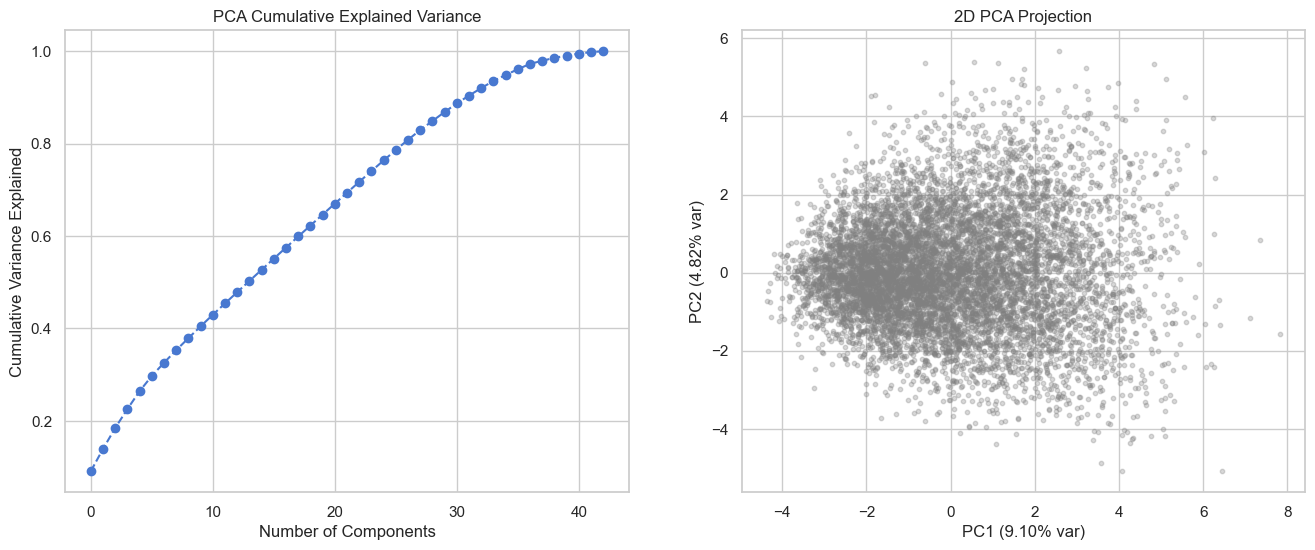

In [5]:
pca_full = PCA().fit(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Cumulative Explained Variance
ax1.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--')
ax1.set_title("PCA Cumulative Explained Variance")
ax1.set_xlabel("Number of Components")
ax1.set_ylabel("Cumulative Variance Explained")
ax1.grid(True)

# 2D Scatter for visualization
X_pca = pca_full.transform(X_scaled)
scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=10, c='gray')
ax2.set_title("2D PCA Projection")
ax2.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.2%} var)")
ax2.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.2%} var)")

plt.show()

### PCA Analysis

The PCA result gives early warning about the clustering problem. The first principal component explains 9.10% of variance and the second explains 4.82%, so together they explain only about 13.92% of total variance. This means that the structure of the data is spread across many dimensions instead of being captured by only two main directions.

The 2D PCA plot also looks like one large cloud rather than separated islands. Because of this, I should not expect very high silhouette scores from the clustering models. This does not mean project failed. It means that chess games may not naturally form a few clean groups using these engineered features.

This PCA result is important because it matches the later clustering results. The weak separation is not only caused by one algorithm. The geometry of the data itself is continuous and overlapping. In other words, tactical, positional, and balanced games may exist as tendencies, but they do not appear as clean separated regions in the first two principal components.

## 6. Benchmarking

As a first benchmark, I used K-Means clustering because it is simple, common in unsupervised learning, and easy to interpret through centroids. The purpose of this first step was not to get the final best model immediately, but to check whether the dataset has any obvious cluster structure.

For this benchmark, I used the full standardized feature set. I compared K-Means with other clustering methods: Gaussian Mixture Models, Agglomerative Clustering, and DBSCAN. This gives a better picture than using only one algorithm, because different clustering methods make different assumptions about cluster shape.

The main evaluation metric is silhouette score. Higher silhouette means that points are closer to their own cluster than to other clusters. In this project, I do not expect extremely high silhouette scores, because chess games may exist on a spectrum instead of forming clean categories.

This benchmark gives a starting point for the rest of the project. If all models show weak separation, then the important question becomes not just “which model is best,” but also “which feature groups create the strongest structure.”

In [6]:
sample_size_eval = min(3000, X_scaled.shape[0])

# K-Means
kmeans_base = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans_base.fit_predict(X_scaled)
sil_kmeans = silhouette_score(X_scaled, labels_kmeans, sample_size=sample_size_eval, random_state=42)

# Gaussian Mixture
gmm_base = GaussianMixture(n_components=3, random_state=42)
labels_gmm = gmm_base.fit_predict(X_scaled)
sil_gmm = silhouette_score(X_scaled, labels_gmm, sample_size=sample_size_eval, random_state=42)

# Agglomerative
agg_base = AgglomerativeClustering(n_clusters=3)
labels_agg = agg_base.fit_predict(X_scaled)
sil_agg = silhouette_score(X_scaled, labels_agg, sample_size=sample_size_eval, random_state=42)

# DBSCAN (Baseline Outlier Detection)
dbscan_base = DBSCAN(eps=2.5, min_samples=10)
labels_dbscan = dbscan_base.fit_predict(X_scaled)

mask_db = labels_dbscan != -1
n_core_points = mask_db.sum()
n_core_clusters = len(set(labels_dbscan[mask_db]))

if n_core_points > 1 and n_core_clusters > 1:
    db_sample_size = min(3000, n_core_points)
    sil_dbscan = silhouette_score(
        X_scaled[mask_db],
        labels_dbscan[mask_db],
        sample_size=db_sample_size,
        random_state=42
    )
else:
    sil_dbscan = np.nan

print("Benchmark Silhouette Scores")
print(f"K-Means (K=3):         {sil_kmeans:.4f}")
print(f"Gaussian Mixture (K=3): {sil_gmm:.4f}")
print(f"Agglomerative (K=3):    {sil_agg:.4f}")
print(f"DBSCAN (Core Clusters): {sil_dbscan:.4f}")

Benchmark Silhouette Scores
K-Means (K=3):         0.0935
Gaussian Mixture (K=3): 0.0489
Agglomerative (K=3):    0.0761
DBSCAN (Core Clusters): 0.0776


### Clustering Results

All clustering models produced relatively low silhouette scores on the full feature set. K-Means with K = 3 gave silhouette score of 0.0935, Gaussian Mixture gave 0.0489, Agglomerative Clustering gave 0.0761, and DBSCAN core clusters gave 0.0776. These values are low, so the clusters are not compact and clearly separated.

This result is not surprising after looking at PCA. The data does not look like separate islands, so the models cannot create very strong clusters without forcing structure. The low scores also suggest that the limitation is not only one specific algorithm. Different clustering methods point to same general conclusion: full feature space does not naturally split into clean chess-style groups.

Because of this, we interpret the clusters carefully. They should not be understood as exact labels like tactical, positional, or balanced. Better interpretation is that clusters represent tendencies in continuous feature space, such as more dynamic games, quieter games, and intermediate games.

This benchmark also motivates the next step of the project. Since full feature space gives weak separation, we compare feature groups separately to see whether dynamic features, structural features, or opening information create stronger clustering signal.

## 7. Feature Group Comparison

This experiment compares clustering quality using different groups of features. This is important because the project is not only asking whether clusters exist, but also what type of chess information creates those clusters.

We separated the features into four groups: all features, dynamic features, structural features, and ECO/opening features. Dynamic features include captures, checks, material volatility, evaluation volatility, and mean absolute evaluation. Structural features include pawn structure, castling timing, center control, king danger, and development-related measures.

If dynamic features produce better silhouette than structural features, then clustering is mainly driven by activity and volatility. If structural features perform better, then pawn structure, king safety, and center control are more important. ECO/opening features are also tested separately because opening family can create structure that is not exactly same as playing style.

In our interpretation, this comparison is more useful than only looking at one final clustering model. It shows which part of the feature engineering actually contributes to separation, and it helps explain why the full feature space may have weak clusters even when some feature groups contain stronger signal.

In [7]:
# Feature group comparison
# This checks whether dynamic, structural, or all features create stronger clustering signal.

dynamic_features = [
    col for col in all_features
    if any(key in col for key in [
        'capture', 'checks', 'material_volatility', 'eval_volatility', 'mean_abs_eval'
    ])
]

structural_features = [
    col for col in all_features
    if any(key in col for key in [
        'dbl_p', 'iso_p', 'pass_p', 'islands', 'center_ctrl', 'king_danger', 'castle', 'minor_moves'
    ])
]

eco_features = [col for col in all_features if col.startswith('eco_group')]

feature_groups = {
    "All Features": list(all_features),
    "Dynamic Features": dynamic_features,
    "Structural Features": structural_features,
    "ECO / Opening Features": eco_features
}

group_results = []

for group_name, cols in feature_groups.items():
    if len(cols) < 2:
        continue
    
    X_group = df_scaled[cols].values
    
    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = km.fit_predict(X_group)
    
    sil = silhouette_score(
        X_group,
        labels,
        sample_size=min(3000, X_group.shape[0]),
        random_state=42
    )
    
    group_results.append({
        "Feature Group": group_name,
        "Number of Features": len(cols),
        "KMeans Silhouette (K=3)": sil
    })

group_results_df = pd.DataFrame(group_results).sort_values(
    by="KMeans Silhouette (K=3)",
    ascending=False
)

display(group_results_df)

,Feature Group,Number of Features,KMeans Silhouette (K=3)
1,Dynamic Features,7,0.277669
3,ECO / Opening Features,20,0.248690
2,Structural Features,16,0.110619
0,All Features,43,0.093463


### Feature Group Comparison Interpretation

The feature group comparison is one of the most important results of the project. Using all 43 features together gave K-Means silhouette score of only 0.0935. However, when we separated features into groups, the result became more informative.

Dynamic features gave the strongest clustering signal with silhouette score 0.2777. ECO/opening features were also strong with silhouette score 0.2487. Structural features gave lower score, about 0.1106, but still slightly higher than using all features together.

This shows that the full feature space contains mixed information. Some features create useful separation, but when all features are combined, weaker or noisier dimensions make the global clusters less clear. The result also supports my interpretation that chess games are not separated into strict style categories. Instead, the clearest tendencies come from activity and volatility, and also from opening family.

This was different from my original expectation. I expected pawn structure and center control to create stronger separation. They still matter, but they did not separate games as clearly as dynamic features such as captures, checks, material volatility, and evaluation volatility.

The strong ECO result should be interpreted carefully. It does not necessarily mean that opening code is same as play style. It means that opening family creates recognizable structure in the data, and some cluster separation may come from opening choice rather than only tactical or positional behavior.

## 8. Hyperparameter Tuning

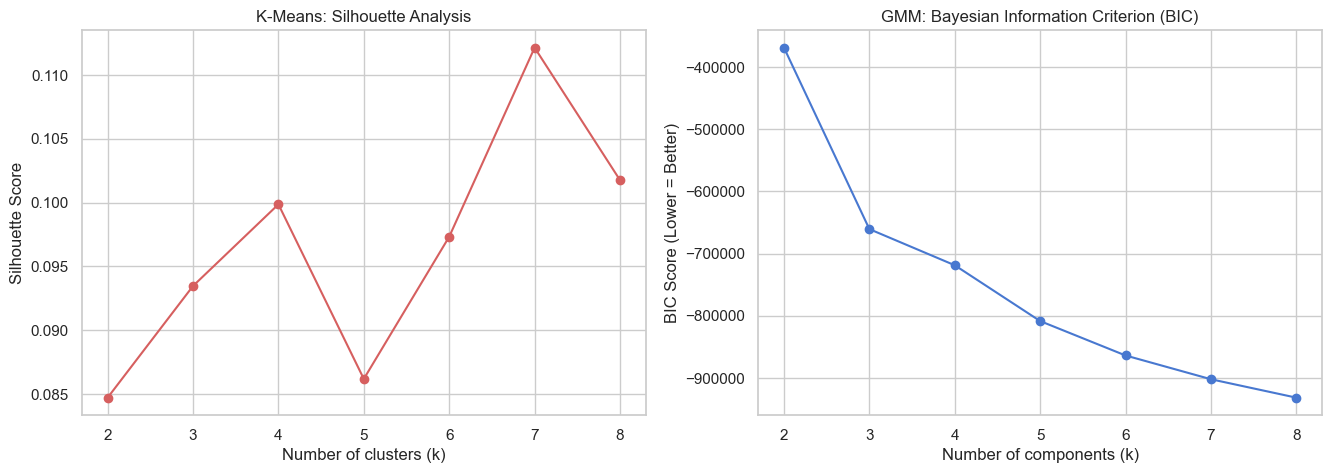

Optimal K based on Silhouette: 7


In [8]:
k_values = range(2, 9)
silhouette_scores_km = []
bic_scores_gmm = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    preds_km = km.fit_predict(X_scaled)
    silhouette_scores_km.append(silhouette_score(X_scaled, preds_km, sample_size=sample_size_eval, random_state=42))
    
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bic_scores_gmm.append(gmm.bic(X_scaled))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(k_values, silhouette_scores_km, 'ro-', label='Silhouette Score')
ax1.set_title("K-Means: Silhouette Analysis")
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Silhouette Score')

ax2.plot(k_values, bic_scores_gmm, 'bo-', label='BIC Score')
ax2.set_title("GMM: Bayesian Information Criterion (BIC)")
ax2.set_xlabel('Number of components (k)')
ax2.set_ylabel('BIC Score (Lower = Better)')

plt.show()

best_k = k_values[np.argmax(silhouette_scores_km)]
print(f"Optimal K based on Silhouette: {best_k}")

### Selection of Number of Clusters

From the silhouette analysis for K-Means, the best value was **K = 7**. However, the improvement over smaller values was modest. The best silhouette score was only around 0.11, so increasing K does not create truly strong clusters.

This indicates that increasing number of clusters allows model to capture finer variations in data, but it does not fundamentally change overall structure. The data does not naturally split into a few clearly distinct groups.

Therefore, I do not interpret K = 7 as seven exact chess styles. It is more useful as a way to divide continuous feature space into smaller regions for interpretation. In other words, K = 7 is a practical modeling choice, not proof that there are seven natural chess categories.

,Seed,Silhouette Score
0,0,0.115611
1,1,0.089208
2,2,0.118871
3,3,0.092556
4,4,0.096552
5,5,0.093347
6,6,0.089756
7,7,0.094309
8,8,0.113209
9,9,0.109622


Mean silhouette across seeds: 0.1013
Std silhouette across seeds: 0.0116


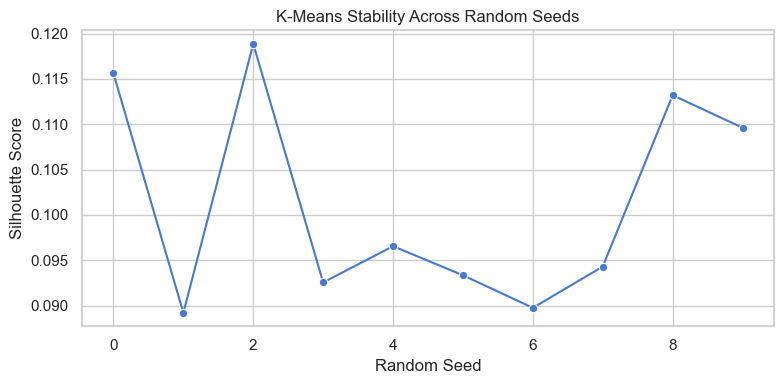

In [9]:
# K-Means stability across random seeds
# This checks whether clustering result is stable or depends too much on initialization.

seed_results = []

for seed in range(10):
    km = KMeans(n_clusters=best_k, random_state=seed, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(
        X_scaled,
        labels,
        sample_size=sample_size_eval,
        random_state=42
    )
    seed_results.append({
        "Seed": seed,
        "Silhouette Score": sil
    })

seed_results_df = pd.DataFrame(seed_results)
display(seed_results_df)

print(f"Mean silhouette across seeds: {seed_results_df['Silhouette Score'].mean():.4f}")
print(f"Std silhouette across seeds: {seed_results_df['Silhouette Score'].std():.4f}")

plt.figure(figsize=(8, 4))
sns.lineplot(data=seed_results_df, x="Seed", y="Silhouette Score", marker="o")
plt.title("K-Means Stability Across Random Seeds")
plt.xlabel("Random Seed")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

### K-Means Stability Check

Because K-Means depends on initialization, I checked whether silhouette score changes across random seeds. The mean silhouette score across seeds was 0.1013 with standard deviation 0.0116.

The scores stayed in the same low range for all seeds. This supports the conclusion that weak separation is not caused by one unlucky initialization. At the same time, the variation between seeds shows that K-Means clusters are not perfectly stable either.

Overall, this stability check supports the main result: there is some clustering signal, but it is weak and overlapping rather than cleanly separated. If the data had very clear natural clusters, the silhouette scores would be higher and less sensitive to initialization.

## 9. Cluster Profiling via Centroid Analysis

After selecting final K-Means model, I analyze the standardized cluster centroids to understand what each cluster represents. This avoids circular reasoning of training another supervised model to explain cluster labels that were already created by clustering.

Because the data was standardized before clustering, centroid values can be interpreted as standard deviations from the dataset average. Positive values mean that feature is above average for that cluster, while negative values mean it is below average.

This step is important because silhouette score only tells how separated clusters are. It does not explain what the clusters mean. Centroid analysis helps connect the mathematical clusters back to chess ideas such as tactical activity, volatility, castling timing, pawn structure, and king danger.

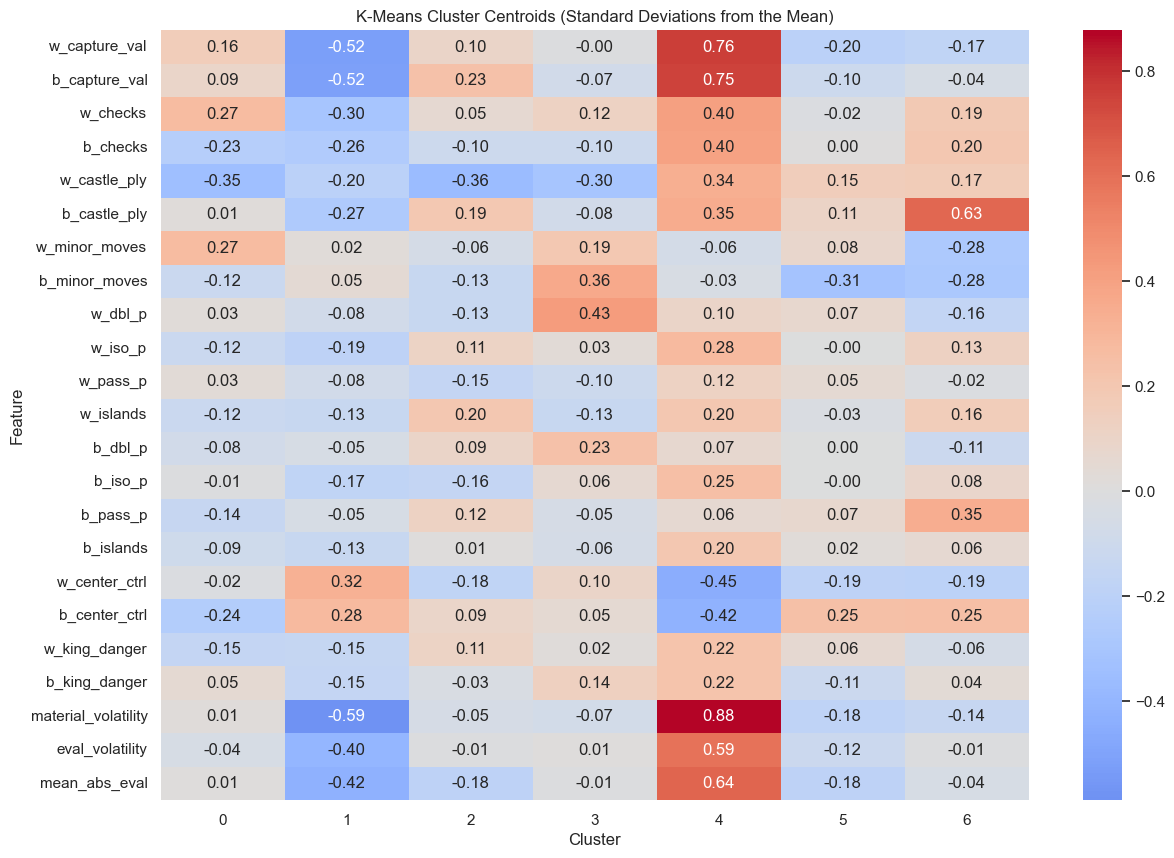

In [10]:
# Final K-Means Implementation
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df['KM_Cluster'] = final_kmeans.fit_predict(X_scaled)

# use standardized centroids to understand each cluster
centroids = pd.DataFrame(final_kmeans.cluster_centers_, columns=all_features)

# keep only chess features, not ECO dummy columns, for heatmap
strategic_features = [col for col in all_features if not col.startswith('eco_group')]

plt.figure(figsize=(14, 10))
sns.heatmap(centroids[strategic_features].T, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("K-Means Cluster Centroids (Standard Deviations from the Mean)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.show()

### Cluster Analysis

The K-Means clusters were not separated very strongly, but centroid heatmap still shows useful tendencies. One cluster has clearly above-average capture values, checks, material volatility, evaluation volatility, and mean absolute evaluation. This cluster can be interpreted as more dynamic or unstable games.

Other clusters have below-average capture values and lower volatility. These look more like quieter games, where material balance and engine evaluation change less during the first 20 moves. There are also clusters with stronger structural signals, such as castling timing, isolated pawns, doubled pawns, or center control.

This supports the feature group comparison. K-Means does not find clean chess styles, but it does separate games along broad axes such as activity, volatility, and opening-related structure. The clusters should be interpreted as tendencies, not exact labels. For example, a cluster with high volatility is not automatically “tactical style,” but it does represent games where the early position changed more sharply.

## 10. DBSCAN Hyperparameter Tuning & Sparse-Region Detection

DBSCAN is very sensitive to `eps` and `min_samples`, so I tested several combinations. The goal was not only to maximize silhouette, because DBSCAN can get high score by keeping only small dense core groups and marking most games as noise.

For this project, DBSCAN is more useful for detecting sparse or unusual regions of the feature space than for producing general chess style clusters. A useful DBSCAN setting should identify dense core groups, but should not treat almost all games as one cluster or all games as true anomalies.

This is why I interpret DBSCAN differently from K-Means. K-Means always forces every game into a cluster, while DBSCAN can say that many games do not belong to a dense region. In this project, that behavior is useful because it tests whether chess games form compact local groups or are spread more continuously across feature space.

,eps,min_samples,Clusters,Noise Rate,Core Silhouette
13,2.8,10,4,0.87375,0.309971
18,3.0,15,4,0.84400,0.296229
17,3.0,10,4,0.82275,0.287909
21,3.3,10,9,0.72075,0.277399
22,3.3,15,4,0.76050,0.268999
23,3.3,20,4,0.77575,0.256745
20,3.3,5,15,0.66050,0.235480
16,3.0,5,12,0.77275,0.153901
0,2.0,5,4,0.97575,0.086646
4,2.3,5,9,0.93975,0.086107



Final DBSCAN identified 4 core clusters and 7272 sparse/noise points (84.35% of data).

Strategic Profile Comparison: Sparse/Noise vs Core Games


DBSCAN_Group,Core,Sparse/Noise
w_capture_val,8.518162,11.429868
b_capture_val,8.958488,11.821232
w_checks,0.147847,0.393101
b_checks,0.115456,0.361248
w_castle_ply,16.987398,22.804730
b_castle_ply,18.120830,25.337321
w_minor_moves,8.646405,8.377338
b_minor_moves,8.473684,8.278878
w_dbl_p,0.028910,0.198295
w_iso_p,0.265382,0.678493


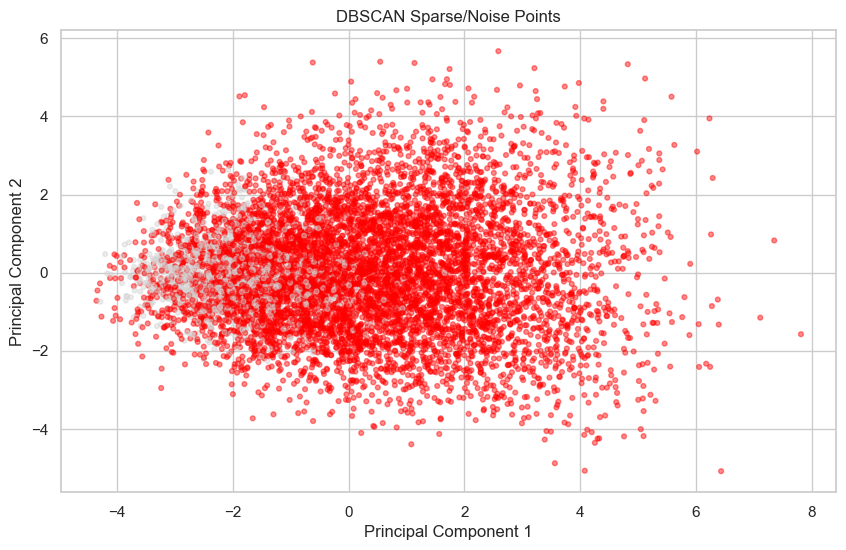

In [11]:
# DBSCAN tuning grid
# We tune eps and min_samples to see how sensitive DBSCAN is.

eps_values = [2.0, 2.3, 2.5, 2.8, 3.0, 3.3]
min_samples_values = [5, 10, 15, 20]

# use sample for DBSCAN tuning because DBSCAN can be slow on full data
db_tune_size = min(4000, X_scaled.shape[0])
rng = np.random.default_rng(42)
db_tune_idx = rng.choice(X_scaled.shape[0], size=db_tune_size, replace=False)
X_db_tune = X_scaled[db_tune_idx]

dbscan_tuning = []

for eps in eps_values:
    for min_samp in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samp)
        labels = db.fit_predict(X_db_tune)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_rate = np.mean(labels == -1)
        
        mask = labels != -1
        if mask.sum() > 1 and len(set(labels[mask])) > 1:
            db_sample_size = min(3000, mask.sum())
            sil = silhouette_score(
                X_db_tune[mask],
                labels[mask],
                sample_size=db_sample_size,
                random_state=42
            )
        else:
            sil = np.nan
        
        dbscan_tuning.append({
            "eps": eps,
            "min_samples": min_samp,
            "Clusters": n_clusters,
            "Noise Rate": noise_rate,
            "Core Silhouette": sil
        })

dbscan_tuning_df = pd.DataFrame(dbscan_tuning)
display(dbscan_tuning_df.sort_values(by="Core Silhouette", ascending=False).head(10))

# Select a balanced parameter set for final anomaly detection
dbscan_final = DBSCAN(eps=2.8, min_samples=15)
df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

n_core = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise = list(df['DBSCAN_Cluster'].values).count(-1)
print(f"\nFinal DBSCAN identified {n_core} core clusters and {n_noise} sparse/noise points ({(n_noise/df.shape[0]):.2%} of data).\n")

# Profile the anomalies vs normal games to understand their strategic characteristics
df['DBSCAN_Group'] = np.where(df['DBSCAN_Cluster'] == -1, 'Sparse/Noise', 'Core')
dbscan_profile = df.groupby('DBSCAN_Group')[strategic_features].mean()

print("Strategic Profile Comparison: Sparse/Noise vs Core Games")
display(dbscan_profile.T.style.background_gradient(cmap='Reds', axis=1))

# Visualize DBSCAN Outliers on PCA
plt.figure(figsize=(10, 6))
colors = np.where(df['DBSCAN_Cluster'] == -1, 'red', 'lightgray')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.45, s=12)
plt.title("DBSCAN Sparse/Noise Points")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### DBSCAN Interpretation

I did not choose DBSCAN setting only by highest core silhouette. Some settings can get high core silhouette by keeping only a small dense core group and marking most games as noise. That is not useful as general clustering result, because it means the method is ignoring most of the dataset.

For final DBSCAN analysis, I used `eps = 2.8` and `min_samples = 15` as a balanced setting. It found 4 core clusters, but still marked 84.35% of games as sparse/noise points. This is too much to interpret as true anomalies. Instead, it shows that feature space does not contain broad dense regions under DBSCAN assumptions.

Even though DBSCAN did not work well as general clustering model, it still gave useful information. The sparse/noise group had higher capture values, more checks, higher king danger, higher material volatility, higher evaluation volatility, and higher mean absolute evaluation than the core group. This suggests that games outside dense regions tend to be more dynamic and unstable.

For this reason, I do not treat DBSCAN as best clustering model for this dataset. I treat it as evidence that chess games are spread continuously, and that sparse regions often correspond to more tactical and volatile games.

## 11. Final Model Comparison

| Model | Main Role | Strength | Weakness | Interpretation |
|---|---|---|---|---|
| K-Means | Main clustering baseline | Easy to interpret with centroids | Forces every game into cluster | Useful for broad tendencies |
| GMM | Soft clustering comparison | Allows probabilistic assignment | Still weak separation | Confirms overlap between groups |
| Agglomerative | Hierarchical comparison | Does not rely on centroid initialization | Harder to scale and interpret | Similar weak separation |
| DBSCAN | Sparse-region detection | Finds dense core groups and sparse points | Marks many games as sparse/noise | Better for studying density structure than assigning general styles |

Overall, no method produced strongly separated clusters in the full feature space. This is important because the limitation is not only one algorithm. K-Means, GMM, Agglomerative Clustering, and DBSCAN all point to the same general conclusion: chess games in this feature space are better described as continuous tendencies than strict style labels.

The strongest separation appeared only after splitting features into groups. Dynamic features and ECO/opening features produced much higher silhouette scores than all features combined. This means that meaningful structure exists, but it is not clean global structure across every feature.

Low silhouette scores should not be interpreted only as model failure. In this project, they are part of the finding. They show that chess games do not naturally separate into a few clean groups using the full engineered feature set. Instead, the feature space behaves more like continuous spectrum.

For this reason, I treat the clustering models as exploratory tools. They help show which parts of the data contain structure, but they do not create final labels like “tactical,” “positional,” or “balanced” with high confidence.

## 12. Summary of Empirical Findings

| Component | Main Result | Interpretation |
|---|---|---|
| **Dataset** | 10,000 parsed games, 8,621 after preprocessing | Large enough local dataset for unsupervised study |
| **Features** | 43 total features after ECO encoding | Satisfies requirement of at least 20 features |
| **PCA** | PC1 + PC2 explain 13.92% variance | No clear 2D separation |
| **Benchmark clustering** | K-Means = 0.0935, GMM = 0.0489, Agglomerative = 0.0761 | Full feature space has weak clusters |
| **Feature groups** | Dynamic = 0.2777, ECO = 0.2487, Structural = 0.1106 | Separation exists more clearly in feature subspaces |
| **K tuning** | Best K-Means result at K = 7, around 0.11 silhouette | More clusters capture detail but not clean styles |
| **K-Means stability** | Mean = 0.1013, std = 0.0116 across seeds | Weak clustering signal is consistent across initialization |
| **DBSCAN** | 4 core clusters, 84.35% sparse/noise points | Density-based clustering struggles with broad continuous feature space |
| **Main conclusion** | Chess styles behave like spectrum | Tactical/positional/balanced are tendencies, not strict labels |

## 13. Changes from the Proposal

The main goal of the project stayed the same as in the proposal: to use unsupervised learning to study chess structures without using outcome labels. However, a few implementation details changed during the project as I tested what was actually useful for clustering.

First, I used the first 20 full moves instead of only the first 15 moves. This gave more stable information about castling, material changes, pawn structure, and early middlegame tension. The analysis still stays focused on the early part of game, but it has more complete chess information.

Second, I added more engineered features than originally planned, especially features related to king danger, center control, volatility, and opening family. This helped the project satisfy the feature requirement and also made it possible to compare dynamic, structural, and ECO/opening feature groups.

Third, I added more clustering models than the initial proposal. The proposal focused mainly on K-Means, DBSCAN, and PCA, but I also included Gaussian Mixture Models and Agglomerative Clustering for comparison. I also added K-Means stability check and DBSCAN hyperparameter tuning, because unsupervised results can depend strongly on initialization and parameter choice.

These changes made the project more complete, but the main direction stayed the same. The project still studies whether chess games have natural structure in feature space, and it still avoids using final game outcome as target label.

## 14. Main Findings

The main findings are:

1. **Clusters are weakly separated in full feature space.** PCA and silhouette scores both show that games do not form clear islands when all features are used together.

2. **Dynamic features give strongest clustering signal.** Dynamic features reached silhouette score 0.2777, much higher than full feature set. This means captures, checks, material volatility, and evaluation volatility are important for separating games.

3. **Opening family also creates strong structure.** ECO/opening features reached silhouette score 0.2487. This suggests that some clustering structure comes from opening choice, not only style of play.

4. **Structural features are weaker but still useful.** Pawn structure, king danger, castling, and center control reached silhouette score 0.1106. They contribute to interpretation, but do not separate games as strongly as dynamic features.

5. **DBSCAN is not good general clustering model here.** It marked 84.35% of games as sparse/noise points in final setting. I do not interpret these as true anomalies. Instead, this shows that chess games do not form broad dense local groups easily in this feature space.

6. **Chess styles behave like spectrum.** Tactical, positional, and balanced games are useful words, but they are not strict natural labels in this feature space.

Overall, the strongest result is not that clustering found perfect chess styles. The strongest result is that full feature space is messy, but dynamic activity and opening family still reveal partial structure.

## 15. Limitations

There are several limitations in this project. First, the features are manually engineered, so they cannot capture every important part of a chess position. For example, long-term plans, piece coordination, piece activity, and weaknesses around king are difficult to describe with simple numerical features.

Second, Stockfish evaluations were sampled only at selected points to save computation time. This makes the project possible on a personal laptop, but it also means that evaluation volatility is only an approximation. A deeper engine search or more frequent evaluation points could give more accurate dynamic features.

Third, the dataset was filtered to remove extreme outliers. This helped the clustering algorithms, because distance-based methods are sensitive to rare extreme values. However, it may also remove some real unusual games. Because of this, the conclusions are mostly about typical games, not every possible chess game.

Fourth, ECO/opening features created strong clustering signal, but this should be interpreted carefully. Opening family is not same thing as chess style. Some of the separation may come from opening choice rather than from tactical or positional behavior.

Finally, unsupervised learning is harder to evaluate than supervised learning. There is no true label for chess style, so silhouette score and interpretability were used together. This means the clusters should be treated as exploratory tendencies, not final ground-truth categories.

## 16. Conclusions

In this project I tried to find natural groups in chess games using unsupervised learning. The dataset was created from 10,000 Lichess PGN games, and each game was converted into numerical features based on the first 20 full moves. After preprocessing and outlier filtering, 8,621 games and 43 features were used for clustering.

The main result is that chess games do not form very clean clusters in the full feature space. PCA showed that first two components explain only about 13.92% of variance, and the 2D projection looked like one large cloud. The clustering models also gave low silhouette scores, with K-Means at 0.0935 for K = 3 and best tuned K-Means only around 0.11.

However, the project still found useful structure. Feature group comparison showed that dynamic features gave much stronger separation, with silhouette score 0.2777. ECO/opening features were also strong, with silhouette score 0.2487. Structural features were weaker, but still gave more signal than all features together. This means that weak global clustering does not mean there is no structure. It means that the structure is partial and depends on which type of chess information is used.

DBSCAN also supported this conclusion. It did not find broad dense clusters and marked 84.35% of games as sparse/noise points in the final setting. This should not be interpreted as most games being true anomalies. Instead, it shows that density-based clustering has difficulty with this continuous chess feature space. The sparse/noise group still had higher capture values and higher volatility, so DBSCAN helped identify more dynamic and unstable regions.

Overall, the project changed my initial expectation. I expected to see clearer groups such as tactical, positional, and balanced games. Instead, the results suggest that these categories are not strict. They are more like tendencies on a spectrum. For future work, I would improve the project by separating games by rating range, controlling for opening family, adding more advanced positional features, and testing whether clusters become clearer inside each opening or rating group.